# Crop Recommendation

## Importing Libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
RANDOM_STATE = 42

sns.set_theme(style = "whitegrid")
pd.set_option("display.max_column", None)

## Loading the dataset

In [21]:
df = pd.read_csv("/content/drive/MyDrive/NBICT LAB PDSML-B-8/11. Crop Recommendation/Crop_recommendation.csv")

## Data Inspection

In [22]:
# Checking the exact column name
print(df.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [23]:
# Auditing data quality
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


### Making Quality Report

In [29]:
Quality_Report = pd.DataFrame(
    {
       "missing_value": df.isna().sum(),
       "unique_values": df.nunique(),
       "data_type": df.dtypes,

    }
)

Quality_Report

,missing_value,unique_values,data_type
N,0,137,int64
P,0,117,int64
K,0,73,int64
temperature,0,2200,float64
humidity,0,2200,float64
ph,0,2200,float64
rainfall,0,2200,float64
label,0,22,object


### Checking Duplicates

In [32]:
print("Duplicate Row:", df.duplicated().sum())

Duplicate Row: 0


### Checking descriptive statistics

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### Checking the target column

In [38]:
print("Number of crops:", df["label"].nunique())

Number of crops: 22


In [41]:
df["label"].value_counts().sort_index()

,count
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


### Visualizing Class balance

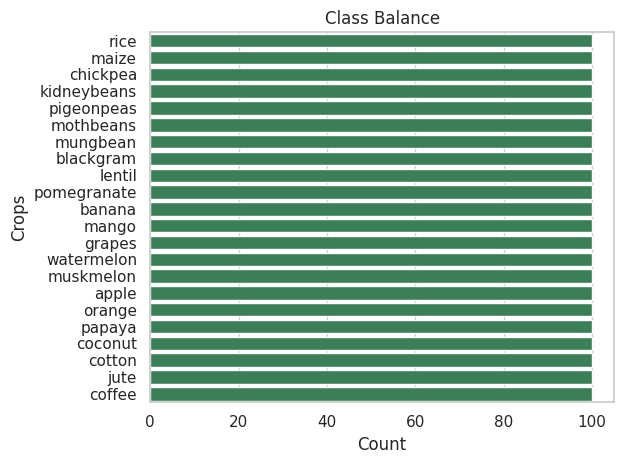

In [49]:
crops = df["label"].value_counts().index
sns.countplot(data = df, y = "label", order = crops, color = 'seagreen')
plt.title("Class Balance")
plt.xlabel("Count")
plt.ylabel("Crops")
plt.tight_layout()

plt.show()
